<a href="https://colab.research.google.com/github/AhmadSyahreza/Katanya-kami-lomba/blob/main/Awal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Katanya Kami Lomba

Notebook ini digunakan untuk coding dan analisis data.

In [12]:
!pip install pandas numpy matplotlib seaborn

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [24]:
train1 = pd.read_csv('/content/drive/MyDrive/Lomba Data/train.csv')
test1 = pd.read_csv('/content/drive/MyDrive/Lomba Data/test.csv')
holidays = pd.read_csv('/content/drive/MyDrive/Lomba Data/holidays.csv')
movies = pd.read_csv('/content/drive/MyDrive/Lomba Data/movies.csv')
ticket_prices = pd.read_csv('/content/drive/MyDrive/Lomba Data/ticket_prices.csv')
test_history = pd.read_csv('/content/drive/MyDrive/Lomba Data/test_history.csv')
sample_submission = pd.read_csv('/content/drive/MyDrive/Lomba Data/sample_submission.csv')

In [16]:
holidays

,date,day_tipe,holiday_tipe,holiday_name
0,2025-04-01,weekday,holiday,Idulfitri 1446 H
1,2025-04-02,weekday,normal,NaN
2,2025-04-03,weekday,normal,NaN
3,2025-04-04,friday,normal,NaN
4,2025-04-05,weekend,normal,NaN
...,...,...,...,...
361,2026-03-28,weekend,normal,NaN
362,2026-03-29,weekend,normal,NaN
363,2026-03-30,weekday,normal,NaN
364,2026-03-31,weekday,normal,NaN


In [17]:
movies

,original_title,age_rating,genre,producer,director,writer,casts
0,120 BAHADUR,Remaja,"Action, War","Farhan Akhtar, Amit Chandrra, Ritesh Sidhwani",Razneesh Ghai,Sumit Arora,"Ankit Siwach, Farhan Akhtar, Amitabh Bachchan,..."
1,"13 DAYS, 13 NIGHTS",Remaja,"Action, War","Dimitri Rassam, Ardavan Safaee",Martin Bourboulon,"Martin Bourboulon, Alexandre Smia, Mohamed Bid...","Roschdy Zem, Lyna Khoudri, Sidse Babett Knudse..."
2,28 YEARS LATER,Dewasa,Thriller,"Danny Boyle, Alex Garland, Peter Rice",Danny Boyle,"Danny Boyle, Alex Garland","Jodie Comer, Aaron Taylor-Johnson, Jack O'Conn..."
3,28 YEARS LATER: THE BONE TEMPLE,Dewasa,Thriller,"Danny Boyle, Alex Garland, Andrew Macdonald",Nia DaCosta,Alex Garland,"Ralph Fiennes, Alfie Williams, Jack O'Connell,..."
4,5 CENTIMETERS PER SECOND (ANIMATION),Remaja,Animation,"Makoto Shinkai, Jin Ho Chung",Makoto Shinkai,Makoto Shinkai,"Kenji Mizuhashi, Yoshimi Kondou, Satomi Hanamu..."
...,...,...,...,...,...,...,...
392,WUTHERING HEIGHTS,Dewasa,"Romance, Drama","Emerald Fennell, Josey McNamara, Margot Robbie",Emerald Fennell,"Emerald Fennell, Emily Bronte","Margot Robbie, Jacob Elordi, Hong Chau, Shazad..."
393,YAKIN NIKAH,Remaja,"Drama, Romance","Shierly Kosasih, Ervina Isleyen",Pritagita Arianegara,"Bene Dion Rajagukguk, Sigit Sulistyo, Erwin Wu","Enzy Storia, Maxime Bouttier, Jourdy Pranata, ..."
394,YOU ARE THE APPLE OF MY EYE,Remaja,"Drama, Romance",Song Dae-chan,Cho Young-myoung,"Giddens Ko, Cho Young-myoung","Jung Jin-young, Kim Da-hyun, Demian, Kim Yo-ha..."
395,YOUR LETTER,Semua Umur,Animation,-,Kim Yong-hwan,Jeong Eun-kyeong,"Lee Suhyun, Kim Min-ju, Min Seung-woo, Nam Doh..."


In [9]:
# from sklearn.model_selection import train_test_split
# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_slice = 0.20, random_state = 0)

In [8]:
# from sklearn.processing import StandardScaler
# sc = StandardScaler()
# X_train = sc.fit_transform(X_train)
# X_test = sc.transform(X_test)

In [58]:
train1["date_show"] = pd.to_datetime(train1["date_show"])
test1["date_show"]  = pd.to_datetime(test1["date_show"])

print("Train shape : ", train1.shape)
print("Test shape : ", test1.shape)

Train shape :  (138959, 7)
Test shape :  (72611, 5)


In [20]:
print("dari :", train1["date_show"].min() , " Sampai : " , train1["date_show"].max())
print("dari :", test1["date_show"].min() , " Sampai : " , test1["date_show"].max())

dari : 2025-10-04 00:00:00  Sampai :  2026-03-27 00:00:00
dari : 2025-10-04 00:00:00  Sampai :  2026-03-27 00:00:00


In [21]:
print("Total Missing value : ", train1.isnull().sum())

Total Missing value :  date_show          66348
cinema_ids             0
city_name              0
movie_title            0
total_ticket           0
occupation_rate        0
total_show             0
dtype: int64


In [22]:
print(train1[["total_ticket", "occupation_rate", "total_show"]].describe())

        total_ticket  occupation_rate     total_show
count  138959.000000    138959.000000  138959.000000
mean      354.122072        28.331061       7.730921
std       725.927987        22.618841      11.005488
min         1.000000         0.000000       1.000000
25%        69.000000        12.360000       3.000000
50%       161.000000        21.840000       5.000000
75%       361.000000        37.010000       8.000000
max     32845.000000       100.000000     285.000000


                 total_ticket  occupation_rate  total_show
total_ticket            1.000            0.309       0.786
occupation_rate         0.309            1.000       0.004
total_show              0.786            0.004       1.000


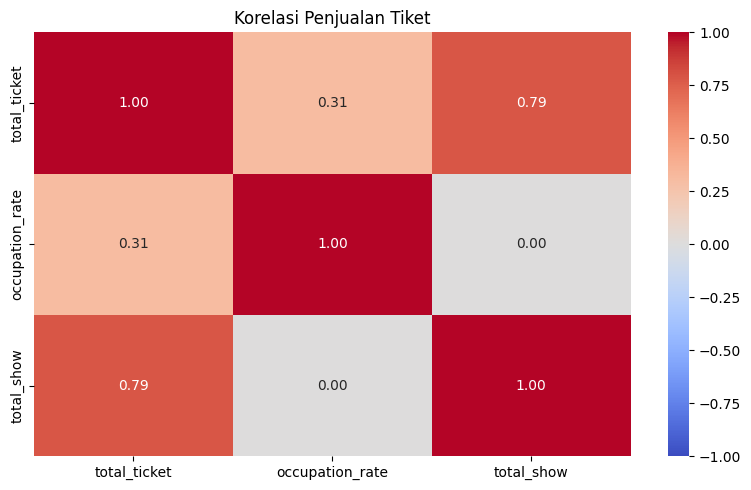

In [23]:
num_cols = [
    "total_ticket",
    "occupation_rate",
    "total_show"
]

corr = train1[num_cols].corr(method="pearson")

print(corr.round(3))

plt.figure(figsize=(8, 5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Korelasi Penjualan Tiket")
plt.tight_layout()
plt.show()

In [39]:
film_test = set(test1['movie_title'])
film_movies = set(movies['original_title'])
film_missing = film_test - film_movies
kota_test = set(test1['city_name'])
kota_prices = set(ticket_prices['city_name'])
kota_missing = kota_test - kota_prices

summary_data = {
    "Kategori Pengecekan": ["Judul Film", "Nama Kota"],
    "Total Unik": [len(film_test), len(kota_test)],
    "Ada": [len(film_test - film_missing), len(kota_test - kota_missing)],
    "Missing": [len(film_missing), len(kota_missing)],
    "Status": [
        " film belum terdaftar" if len(film_missing) > 0 else "",
        " kota belum terdaftar" if len(kota_missing) > 0 else ""
    ]
}

df_summary = pd.DataFrame(summary_data)
display(df_summary)

,Kategori Pengecekan,Total Unik,Ada,Missing,Status
0,Judul Film,160,140,20,film belum terdaftar
1,Nama Kota,69,69,0,


In [55]:
df_missing_movies = pd.DataFrame({
    "Judul Missing": sorted((film_missing))
})

display(df_missing_movies)

,Judul Missing
0,AVATAR: FIRE AND ASH (3D)
1,AVATAR: FIRE AND ASH (IMAX 3D)
2,BLADES OF THE GUARDIANS (IMAX 2D)
3,DANUR: THE LAST CHAPTER (IMAX 2D)
4,EPIC: ELVIS PRESLEY IN CONCERT (IMAX 2D)
5,HOPPERS (3D)
6,HOPPERS (IMAX 2D)
7,MERCY (IMAX 2D)
8,PREDATOR: BADLANDS (3D)
9,PREDATOR: BADLANDS (IMAX 2D)


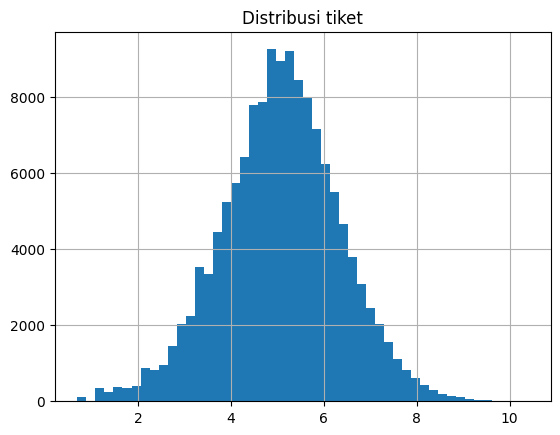

In [54]:
np.log1p(train1['total_ticket']).hist(bins=50)
plt.title('Distribusi tiket')
plt.show()

In [68]:
def find_d1(df):
    nat = df.groupby(['movie_title','date_show'])['total_ticket'].sum().reset_index()
    first = nat.groupby('movie_title')['date_show'].min()
    out = {}
    for m, g in nat.groupby('movie_title'):
        ds = set(g['date_show'])
        for d in sorted(ds):
            if {d + pd.Timedelta(days=1), d + pd.Timedelta(days=2)} <= ds:
                out[m] = d
                break
    f = pd.Series(out, name='D1').rename_axis('movie_title').reset_index()
    f['first_date'] = f['movie_title'].map(first)
    return f

f = find_d1(train1)
tmin, tmax = train1['date_show'].min(), train1['date_show'].max()
f = f[(f['D1'] > tmin + pd.Timedelta(days=2)) &
      (f['D1'] + pd.Timedelta(days=9) <= tmax) &
      ((f['D1'] - f['first_date']).dt.days <= 3)].reset_index(drop=True)

print("jumlah film :", len(f), "dari", train1['movie_title'].nunique())
f.head()

jumlah film : 108 dari 237


,movie_title,D1,first_date
0,28 YEARS LATER,2025-06-17,2025-06-17
1,A BIG BOLD BEAUTIFUL JOURNEY,2025-09-18,2025-09-18
2,A MINECRAFT MOVIE,2025-04-04,2025-04-04
3,A MINECRAFT MOVIE (3D),2025-04-09,2025-04-09
4,A MINECRAFT MOVIE (IMAX 2D),2025-04-08,2025-04-08
